In [70]:
import ultranest
import george
import numpy as np
import matplotlib.pyplot as plt
from ultranest.plot import cornerplot
from ultranest import ReactiveNestedSampler
from ultranest.plot import PredictionBand
from george.modeling import Model
from george import kernels, GP
from scipy.optimize import minimize
from time import time

#%matplotlib widget
#plt.close('all')

## Load dataset

File creati e caricati correttamente!
Mesi caricati (Sezione Aria): 2100
Mesi caricati (Sezione Acqua): 2100


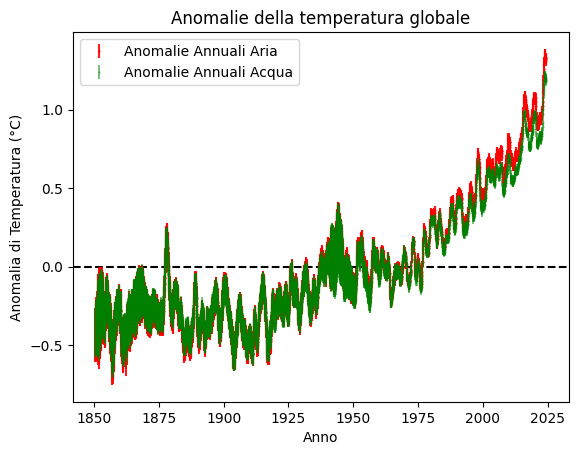

In [3]:
filename = 'Land_and_Ocean_complete.txt'
separator = "% Global Average Temperature Anomaly with Sea Ice Temperature Inferred from Water Temperatures"

with open(filename, 'r') as f:
    content = f.read()

parts = content.split(separator)

with open('data_air.txt', 'w') as f:
    f.write(parts[0])

with open('data_water.txt', 'w') as f:
    f.write(separator + parts[1])

data_air_raw = np.genfromtxt('data_air.txt', comments='%', filling_values=np.nan)
data_water_raw = np.genfromtxt('data_water.txt', comments='%', filling_values=np.nan)

print("File creati e caricati correttamente!")
def to_dict(raw):
    # Tempo in anni decimali: Anno + (Mese - 0.5)/12
    years = raw[:, 0]
    months = raw[:, 1]
    time_years = years + (months - 0.5) / 12
    t_ref = np.min(years)
    time_centered = time_years - t_ref
    return {
        "time_years": time_years,
        "time_centered": time_centered,
        "Year": raw[:,0].astype(int), 
        "Month": raw[:,1].astype(int), 
        "Monthly_Anomaly": raw[:,2], 
        "Monthly_Anomaly_Unc": raw[:,3], 
        "Annual_Anomaly": raw[:,4], 
        "Annual_Anomaly_Unc": raw[:,5], 
        "Five_Year_Anomaly": raw[:,6], 
        "Five_Year_Anomaly_Unc": raw[:,7], 
        "Ten_Year_Anomaly": raw[:,8], 
        "Ten_Year_Anomaly_Unc": raw[:,9], 
        "Twenty_Year_Anomaly": raw[:,10], 
        "Twenty_Year_Anomaly_Unc": raw[:,11], 
    }

data_air = to_dict(data_air_raw)
data_water = to_dict(data_water_raw)

print(f"Mesi caricati (Sezione Aria): {len(data_air['Year'])}")
print(f"Mesi caricati (Sezione Acqua): {len(data_water['Year'])}")

plt.Figure(figsize=(10, 6))
plt.errorbar(data_air['time_years'], data_air['Annual_Anomaly'], yerr=data_air['Annual_Anomaly_Unc'], fmt='.r', markersize=1, zorder=1, alpha=0.9, label='Anomalie Annuali Aria')
plt.errorbar(data_water['time_years'], data_water['Annual_Anomaly'], yerr=data_water['Annual_Anomaly_Unc'], fmt='.g', markersize=1, zorder=2, alpha=0.5, label='Anomalie Annuali Acqua')
plt.xlabel('Anno')
plt.ylabel('Anomalia di Temperatura (°C)')
plt.title('Anomalie della temperatura globale')
plt.axhline(0, color='black', linestyle='--', zorder=0)
plt.legend()
plt.show()

## Models definition

In [4]:
def constant_model(t, intercept):
    return intercept + t*0

def linear_model(t, a, b):
    return b + a*t

def quadratic_model(t, a, b, c):
    return c + b*t + a*t**2

def exponential_model(t, a, b, c):
    return a * np.exp(b*t) + c

In [5]:
param_constant = ['intercept']
param_linear = ['a', 'b']
param_quadratic = ['a', 'b', 'c']
param_exponential = ['a', 'b', 'c']

def prior_constant(cube):

    params = cube.copy()

    params[0] = cube[0] * 10 - 5

    return params

def prior_linear(cube):

    params = cube.copy()

    params[0] = cube[0] * 10
    params[1] = cube[1] * 10 - 5

    return params

def prior_quadratic(cube):

    params = cube.copy()

    params[0] = cube[0] * 2 - 1
    params[1] = cube[1] * 10 - 5
    params[2] = cube[2] * 10 - 5

    return params

def prior_exponential(cube):

    params = cube.copy()

    params[0] = cube[0] * 2.0
    params[1] = cube[1] * 0.05
    params[2] = cube[2] * 10 - 5
    
    return params

def log_likelihood_constant(params, data):
    
    intercept = params

    model = constant_model(data['time_centered'], intercept)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2+np.log(2*np.pi*data['Annual_Anomaly_Unc']**2))

    loglike = -0.5 * chi2

    return loglike

def log_likelihood_linear(params, data):
    
    a, b = params

    model = linear_model(data['time_centered'], a, b)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2)

    loglike = -0.5 * chi2

    return loglike

def log_likelihood_quadratic(params, data):
    
    a, b, c = params

    model = quadratic_model(data['time_centered'], a, b, c)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2+np.log(2*np.pi*data['Annual_Anomaly_Unc']**2))

    loglike = -0.5 * chi2

    return loglike

def log_likelihood_exponential(params, data):
    
    a, b, c = params

    model = exponential_model(data['time_centered'], a, b, c)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2+np.log(2*np.pi*data['Annual_Anomaly_Unc']**2))

    loglike = -0.5 * chi2

    return loglike

## Ultranest 

In [6]:
datasets = {
    'air': data_air,
    'water': data_water
}

models_config = {
    'const': (param_constant, log_likelihood_constant, prior_constant),
    'linear': (param_linear, log_likelihood_linear, prior_linear),
    'quadratic': (param_quadratic, log_likelihood_quadratic, prior_quadratic),
    'exponential': (param_exponential, log_likelihood_exponential, prior_exponential),
}

results = {}
samplers = {}

for model_label, (params, loglike_fn, prior_fn) in models_config.items():
    for data_label, data in datasets.items():
        
        run_id = f"{data_label}_{model_label}" 
        print(f"STARTING RUN: {run_id.upper()}")
        
        sampler = ReactiveNestedSampler(
            params, 
            lambda p, d=data: loglike_fn(p, d), 
            prior_fn
        )
        
        res = sampler.run(min_num_live_points=400, dKL=np.inf, min_ess=100)

        samplers[run_id] = sampler
        results[run_id] = res
        
        print(f"\nDONE: {run_id}")
        sampler.print_results()

STARTING RUN: AIR_CONST
[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-8e+04  -81416.72 [-81416.7252..-81416.7251]*| it/evals=4640/5191 eff=96.8483% N=400 0   0  
[ultranest] Likelihood function evaluations: 5217
[ultranest]   logZ = -8.143e+04 +- 0.1028
[ultranest] Effective samples strategy satisfied (ESS = 1251.4, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.05 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.11, need <0.5)
[ultranest]   logZ error budget: single: 0.14 bs:0.10 tail:0.04 total:0.11 required:<0.50
[ultranest] done iterating.

DONE: air_const

logZ = -81425.081 +- 0.203
  single instance: logZ = -81425.081 +- 0.140
  bootstrapped   : logZ = -81425.089 +- 0.200
  tail           : logZ = +- 0.036
insert order U test : converged: True correlation: inf iterations

    intercept           : 0.3450│ ▁▁ ▁▁▁▁▁▁▁▂▂▃▄▄▅▆▇▇▇▇▆▅▄▆▄▃▂▂▁▁▁▁▁▁▁▁ │0.3530    0.3491 +- 0.0010

STARTING RUN: WATER_CONST
[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-7e+04  -74211.44 [-74211.4405..-74211.4405]*| it/evals=4590/5119 eff=97.2664% N=400 0   0  
[ultranest] Likelihood function evaluations: 5124
[ultranest]   logZ = -7.422e+04 +- 0.1359
[ultranest] Effective samples strategy satisfied (ESS = 1238.4, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.47+-0.08 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.14, need <0.5)
[ultranest]   logZ error budget: single: 0.14 bs:0.14 tail:0.04 total:0.14 required:<0.50
[ultranest] done iterating.

DONE: water_const

logZ = -74219.678 +- 0.220
  single instance: logZ = -74219.678 +- 0.139
  bootstrapped   : logZ = -74219.708 +- 0.217
  tail           : logZ = +- 0.038
insert order U test : converged: True correlation: inf iterations

    intercept           : 0.31559│ ▁▁▁▁▁▁▁▁▂▂▃▄▄▅▆▇▆▇▆▇▄▅▅▃▃▂▂▁▁▁▁▁▁ ▁ ▁ │0.32328    0.31918 +- 0.00095

STARTING RUN: AIR_LINEAR
[ultranest] Sampling 400 live points from prior ...

[ultranest] Explored until L=-2e+04  -20185.62 [-20185.6259..-20185.6258]*| it/evals=10000/13529 eff=76.1673% N=400   0     
[ultranest] Likelihood function evaluations: 13567
[ultranest]   logZ = -2.021e+04 +- 0.1522
[ultranest] Effective samples strategy satisfied (ESS = 1597.6, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.47+-0.08 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.15, need <0.5)
[ultranest]   logZ error budget: single: 0.22 bs:0.15 tail:0.01 total:0.15 required:<0.50
[ultranest] done iterating.

DONE: air_linear

logZ = -20206.083 +- 0.297
  single instance: logZ = -20206.083 +- 0.221
  bootstrapped   : logZ = -20206.131 +- 0.297
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.009903│ ▁▁▁▁▁▁▁▁▁▁▂▃▄▅▄▆▆▇▇▇▇▆▅▄▄▃▂▂▁▁▁▁▁▁▁▁▁ │0.010144    0.010023 +- 0.000028
    b                   : -0.9840│ ▁  ▁▁▁▁▁▁▁▂▂▃▃▄▆▆▆▇▇▇▇▆▅▄▃▃▂▂▁▁▁▁▁▁

[ultranest] Explored until L=-2e+04  -18230.81 [-18230.8231..-18230.8230]*| it/evals=10080/13698 eff=75.8009% N=400   0   0  
[ultranest] Likelihood function evaluations: 13725
[ultranest]   logZ = -1.825e+04 +- 0.1685
[ultranest] Effective samples strategy satisfied (ESS = 1600.8, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.07 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.17, need <0.5)
[ultranest]   logZ error budget: single: 0.22 bs:0.17 tail:0.01 total:0.17 required:<0.50
[ultranest] done iterating.

DONE: water_linear

logZ = -18251.459 +- 0.345
  single instance: logZ = -18251.459 +- 0.222
  bootstrapped   : logZ = -18251.420 +- 0.345
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.009042│ ▁▁▁▁▁▁▁▁▂▂▂▄▄▆▆▇▆▇▇▆▅▅▄▃▃▂▁▁▁▁▁▁▁▁▁ ▁ │0.009262    0.009145 +- 0.000026
    b                   : -0.9114│ ▁  ▁▁▁▁▁▁▁▁▂▃▃▄▄▆▇▆▇▇▇▇▅▄▄▂▂▁▁▁▁

[ultranest] Explored until L=-2e+03  138.32 [-2138.3765..-2138.3763]*| it/evals=15520/29590 eff=53.1689% N=400    0   00   0  
[ultranest] Likelihood function evaluations: 29636
[ultranest]   logZ = -2173 +- 0.2009
[ultranest] Effective samples strategy satisfied (ESS = 1898.7, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.09 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.20, need <0.5)
[ultranest]   logZ error budget: single: 0.29 bs:0.20 tail:0.01 total:0.20 required:<0.50
[ultranest] done iterating.

DONE: air_quadratic

logZ = -2172.617 +- 0.429
  single instance: logZ = -2172.617 +- 0.286
  bootstrapped   : logZ = -2172.591 +- 0.429
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.00009936│ ▁▁ ▁▁▁▁▁▁▁▁▂▃▄▄▅▆▇▇▇▆▆▅▅▄▃▂▁▁▁▁▁▁▁ ▁▁ │0.00010488    0.00010217 +- 0.00000061
    b                   : -0.01198│ ▁▁▁▁▁▁▁▁▁▂▂▃▄▅▅▇▆▇▇▇▆▆▄▄▄▂▂▁▁

[ultranest] Explored until L=-2e+03  948.94 [-1948.9991..-1948.9990]*| it/evals=15560/29899 eff=52.7476% N=400    0   0   0   
[ultranest] Likelihood function evaluations: 29909
[ultranest]   logZ = -1983 +- 0.1852
[ultranest] Effective samples strategy satisfied (ESS = 1888.2, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.07 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.19, need <0.5)
[ultranest]   logZ error budget: single: 0.29 bs:0.19 tail:0.01 total:0.19 required:<0.50
[ultranest] done iterating.

DONE: water_quadratic

logZ = -1983.283 +- 0.272
  single instance: logZ = -1983.283 +- 0.287
  bootstrapped   : logZ = -1983.322 +- 0.272
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.00008701│ ▁ ▁▁▁▁▁▁▁▁▁▂▂▃▄▆▆▇▇▇▆▇▇▆▄▄▃▂▁▁▁▁▁▁▁▁▁ │0.00009205    0.00008970 +- 0.00000057
    b                   : -0.01025│ ▁▁▁▁▁▁▁▁▁▂▃▃▅▅▆▇▇▇▇▇▇▆▆▄▃▂▂

[ultranest] Explored until L=-2e+03  681.17 [-1681.2241..-1681.2240]*| it/evals=10640/115540 eff=9.2409% N=400   0   0   0 
[ultranest] Likelihood function evaluations: 115597
[ultranest]   logZ = -1703 +- 0.1404
[ultranest] Effective samples strategy satisfied (ESS = 1879.1, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.09 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.14, need <0.5)
[ultranest]   logZ error budget: single: 0.23 bs:0.14 tail:0.01 total:0.14 required:<0.50
[ultranest] done iterating.

DONE: air_exponential

logZ = -1703.250 +- 0.281
  single instance: logZ = -1703.250 +- 0.227
  bootstrapped   : logZ = -1703.266 +- 0.281
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.02900│ ▁   ▁▁▁▁▁▁▁▂▂▃▄▅▅▆▇▇▇▇▆▄▅▄▃▂▁▁▁▁▁▁▁▁▁ │0.03708    0.03334 +- 0.00093
    b                   : 0.02148│ ▁▁▁▁▁▁▁▁▁▂▄▅▅▅▇▇▇▇▆▅▅▄▃▂▂▁▁▁▁▁▁▁    ▁ │0.0

[ultranest] Explored until L=-2e+03  687.33 [-1687.3914..-1687.3913]*| it/evals=10560/175359 eff=6.0357% N=400       0  0 
[ultranest] Likelihood function evaluations: 175434
[ultranest]   logZ = -1709 +- 0.1832
[ultranest] Effective samples strategy satisfied (ESS = 1882.0, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.05 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.18, need <0.5)
[ultranest]   logZ error budget: single: 0.23 bs:0.18 tail:0.01 total:0.18 required:<0.50
[ultranest] done iterating.

DONE: water_exponential

logZ = -1709.255 +- 0.378
  single instance: logZ = -1709.255 +- 0.226
  bootstrapped   : logZ = -1709.223 +- 0.378
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.0310│ ▁ ▁▁▁▁▁▁▁▃▃▃▄▆▆▇▇▇▇▆▇▆▅▄▃▂▂▁▁▁▁▁▁▁▁ ▁ │0.0399    0.0353 +- 0.0011
    b                   : 0.02053│ ▁▁▁▁▁▁▁▁▁▂▃▃▄▅▆▆▇▇▇▇▇▅▅▄▃▃▂▁▁▁▁▁▁▁▁▁▁ │0.0218

## Constant fit

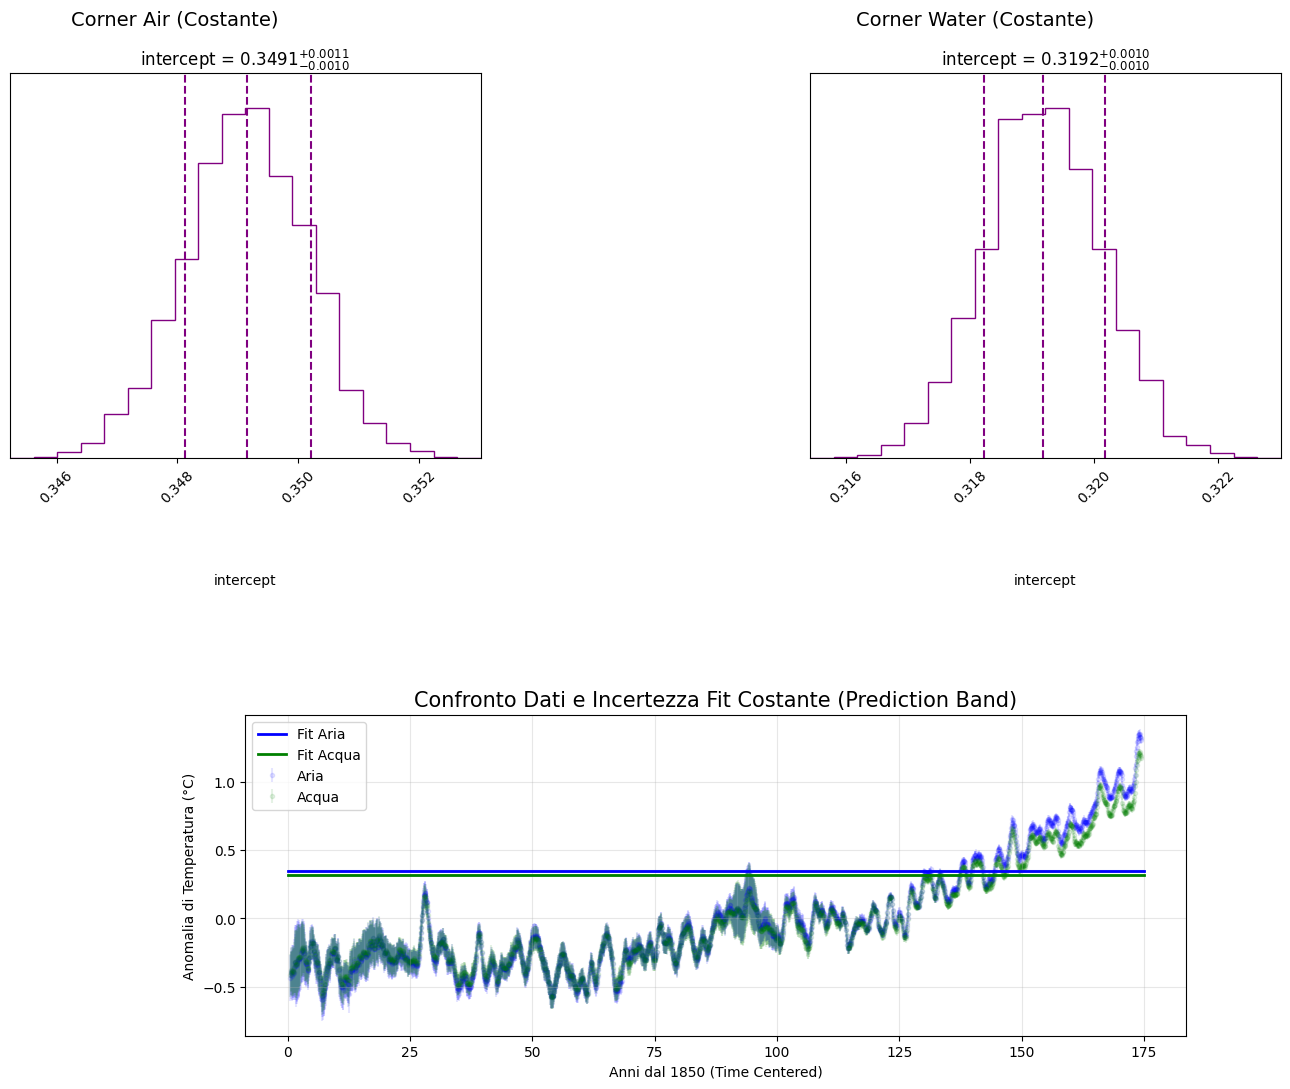

In [7]:
fig = plt.figure(figsize=(16, 12))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.2, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_const'], fig=corner_subfigs[0], title_fmt='.4f')
corner_subfigs[0].suptitle('Corner Air (Costante)', fontsize=14)

cornerplot(results['water_const'], fig=corner_subfigs[1], title_fmt='.4f')
corner_subfigs[1].suptitle('Corner Water (Costante)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

t_min = min(data_air['time_centered'].min(), data_water['time_centered'].min())
t_max = max(data_air['time_centered'].max(), data_water['time_centered'].max())
t_grid = np.linspace(t_min, t_max, 400)

def add_constant_band(ax, res_key, data, color, label_prefix):
    samples = results[res_key]['samples']
    band = PredictionBand(t_grid)

    for val in samples:
        band.add(np.full_like(t_grid, val))
    
    ax.errorbar(data['time_centered'], data['Annual_Anomaly'], 
                yerr=data['Annual_Anomaly_Unc'], fmt='.', color=color, alpha=0.1, zorder=1, label =f'{label_prefix}')
    
    band.line(ax=ax, color=color, lw=2, label=f'Fit {label_prefix}', zorder=3)
    band.shade(ax=ax, color=color, alpha=0.3, zorder=2)        # 1-sigma (68%)
    band.shade(ax=ax, q=0.49, color=color, alpha=0.1, zorder=2) # 2-sigma (95% approx)

add_constant_band(ax, 'air_const', data_air, 'blue', 'Aria')
add_constant_band(ax, 'water_const', data_water, 'green', 'Acqua')

ax.set_title('Confronto Dati e Incertezza Fit Costante (Prediction Band)', fontsize=15)
ax.set_xlabel('Anni dal 1850 (Time Centered)')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.show()

## Linear fit

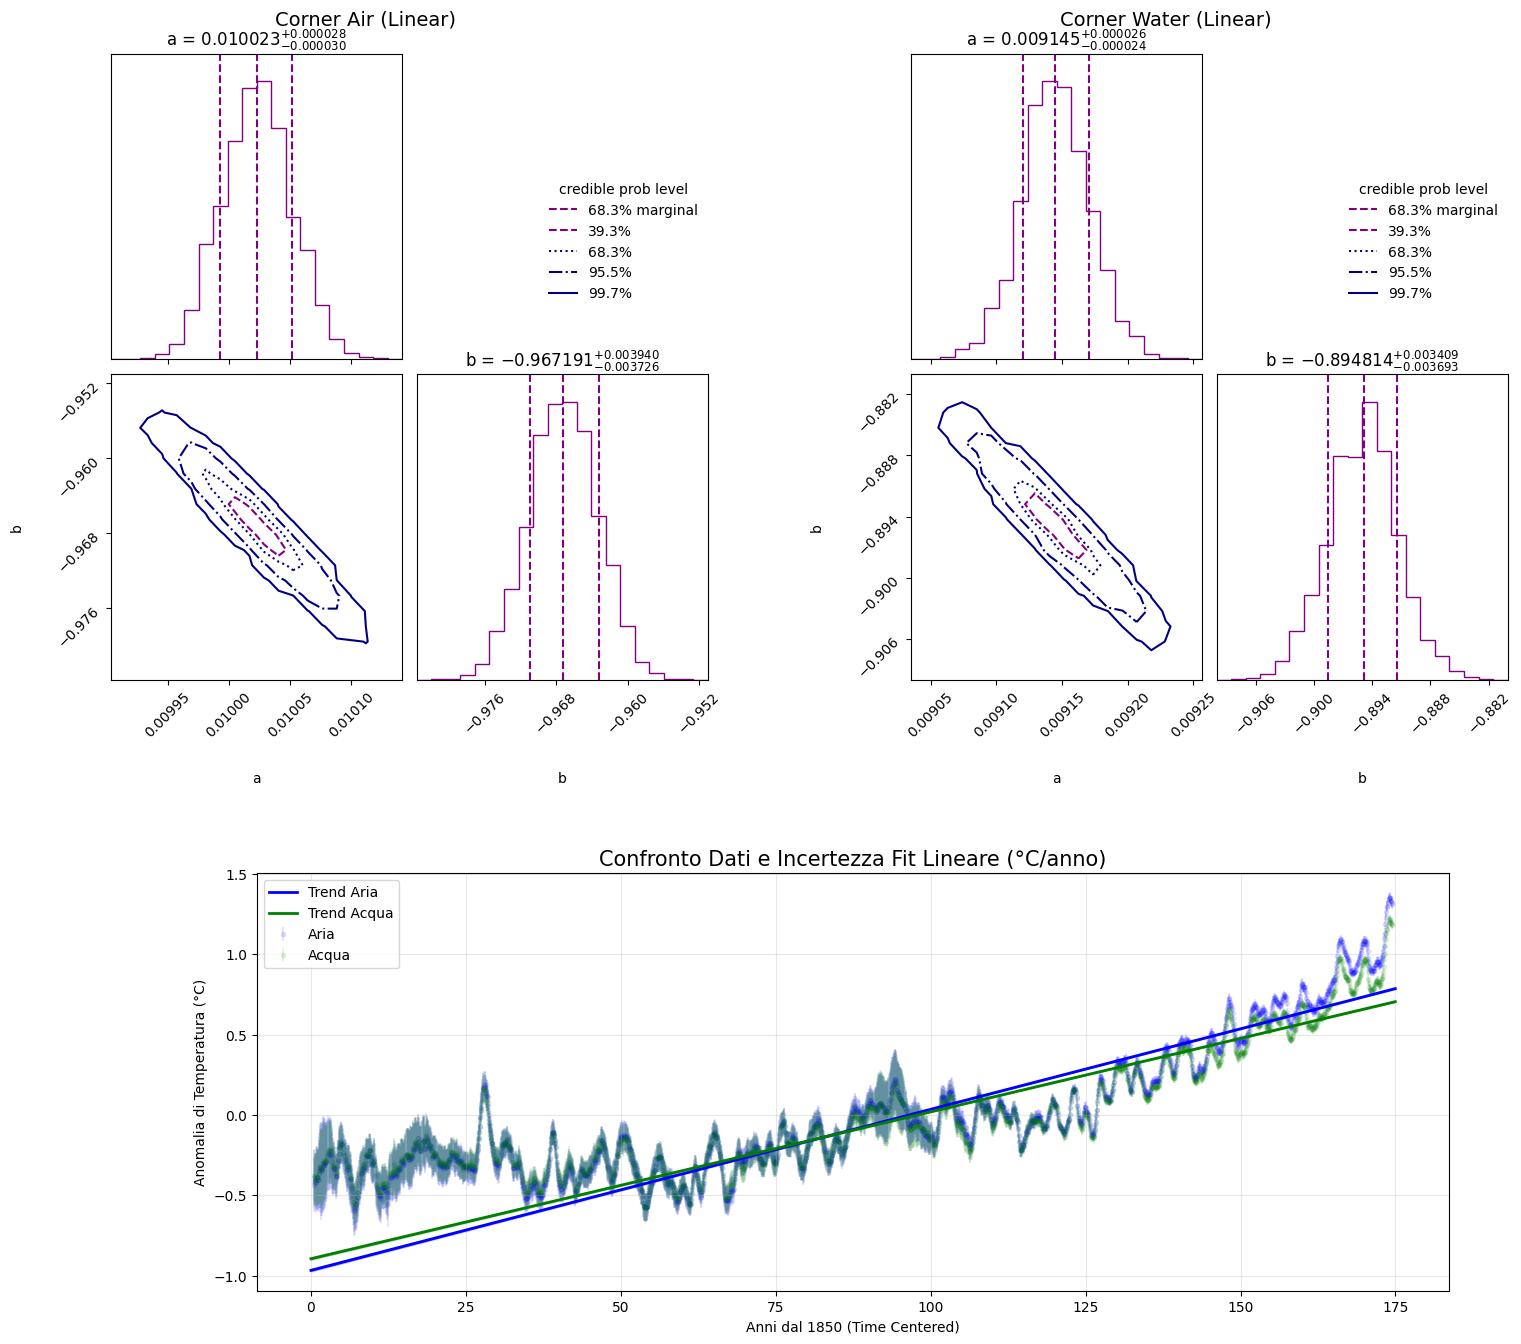

In [8]:
fig = plt.figure(figsize=(16, 14))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.5, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_linear'], fig=corner_subfigs[0], title_fmt='.6f')
corner_subfigs[0].suptitle('Corner Air (Linear)', fontsize=14)

cornerplot(results['water_linear'], fig=corner_subfigs[1], title_fmt='.6f')
corner_subfigs[1].suptitle('Corner Water (Linear)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

t_min = min(data_air['time_centered'].min(), data_water['time_centered'].min())
t_max = max(data_air['time_centered'].max(), data_water['time_centered'].max())
t_grid = np.linspace(t_min, t_max, 400)

def plot_linear_with_bands(ax, data, res_key, color, label_prefix):
    samples = results[res_key]['samples']

    band = PredictionBand(t_grid)

    for a, b in samples:
        band.add(a * t_grid + b)
        
    ax.errorbar(data['time_centered'], data['Annual_Anomaly'], 
                yerr=data['Annual_Anomaly_Unc'], fmt='.', color=color, alpha=0.1, zorder=1, label=f'{label_prefix}')
    
    band.line(ax=ax, color=color, lw=2, label=f'Trend {label_prefix}', zorder=3)
    band.shade(ax=ax, color=color, alpha=0.3, zorder=2)        # 1-sigma
    band.shade(ax=ax, q=0.49, color=color, alpha=0.1, zorder=2) # 2-sigma

plot_linear_with_bands(ax, data_air, 'air_linear', 'blue', 'Aria')
plot_linear_with_bands(ax, data_water, 'water_linear', 'green', 'Acqua')

ax.set_title('Confronto Dati e Incertezza Fit Lineare (°C/anno)', fontsize=15)
ax.set_xlabel('Anni dal 1850 (Time Centered)')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.show()

## Quadratic fit

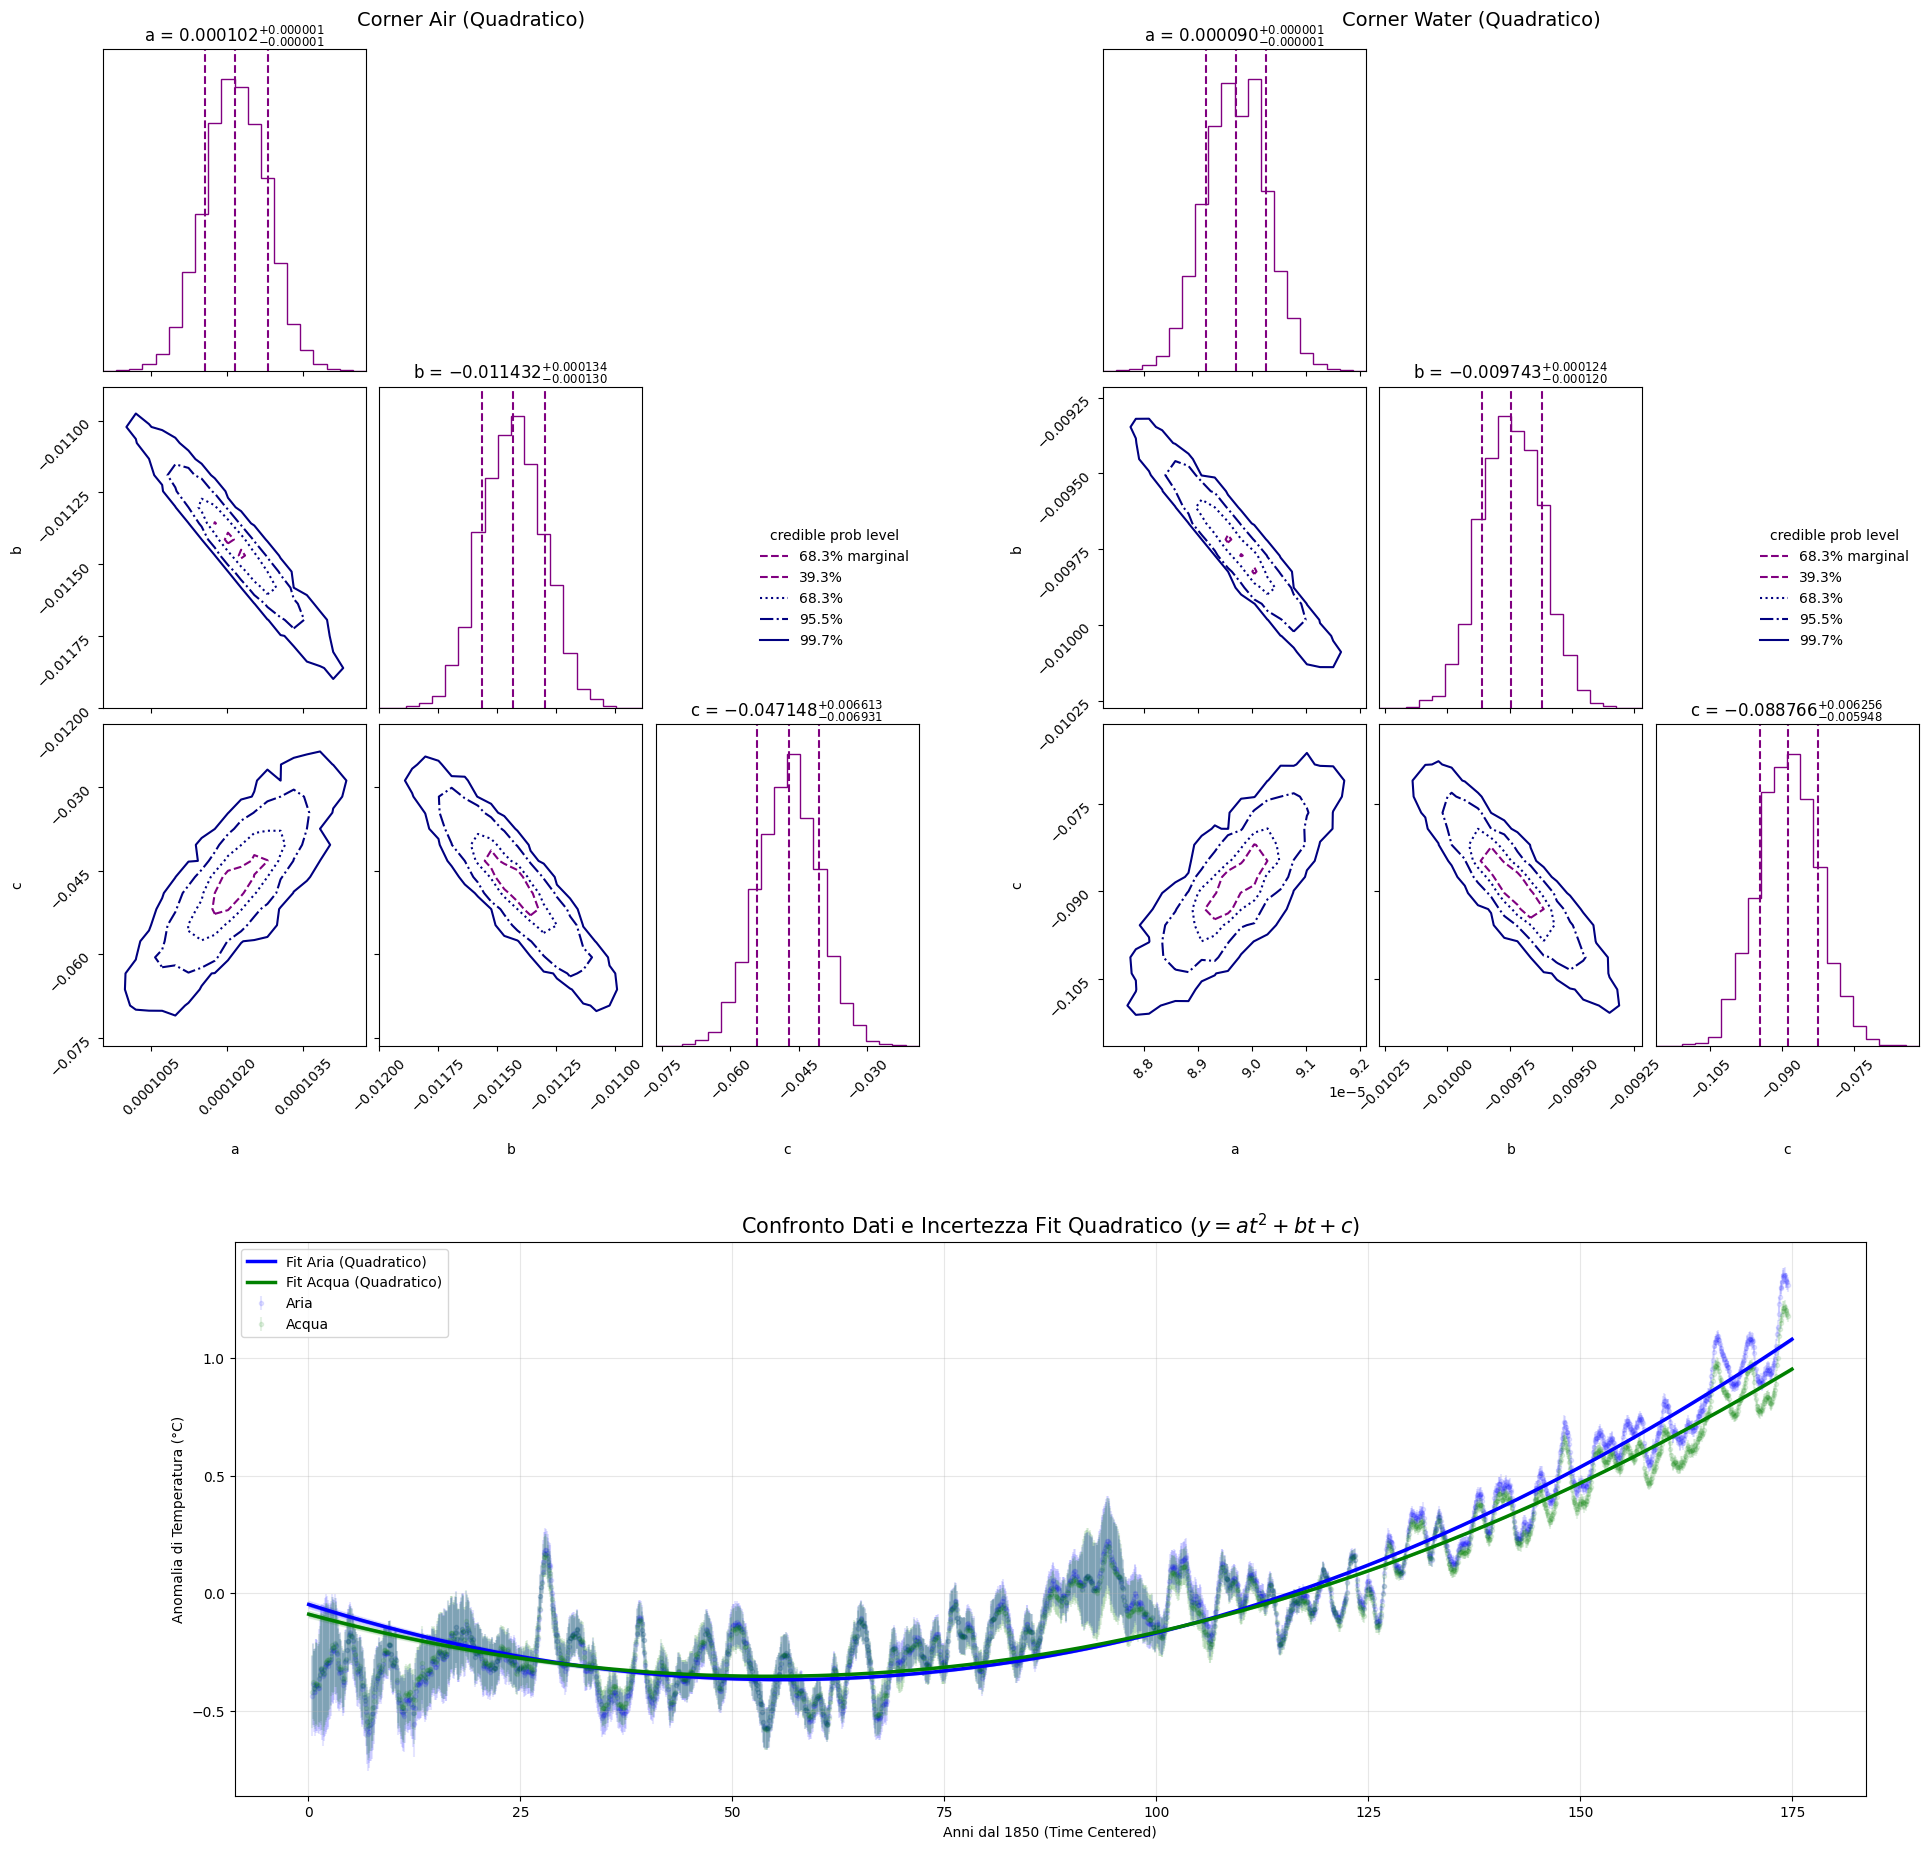

In [9]:
fig = plt.figure(figsize=(20, 19))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.8, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_quadratic'], fig=corner_subfigs[0], title_fmt='.6f')
corner_subfigs[0].suptitle('Corner Air (Quadratico)', fontsize=14)

cornerplot(results['water_quadratic'], fig=corner_subfigs[1], title_fmt='.6f')
corner_subfigs[1].suptitle('Corner Water (Quadratico)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

t_min = min(data_air['time_centered'].min(), data_water['time_centered'].min())
t_max = max(data_air['time_centered'].max(), data_water['time_centered'].max())
t_grid = np.linspace(t_min, t_max, 400)

def plot_quadratic_with_bands(ax, data, res_key, color, label_prefix):
    samples = results[res_key]['samples']
    
    band = PredictionBand(t_grid)
    
    for a, b, c in samples:
        band.add(a * t_grid**2 + b * t_grid + c)
    
    ax.errorbar(data['time_centered'], data['Annual_Anomaly'], 
                yerr=data['Annual_Anomaly_Unc'], fmt='.', color=color, alpha=0.1, zorder=1, label= f'{label_prefix}')

    band.line(ax=ax, color=color, lw=2.5, label=f'Fit {label_prefix} (Quadratico)', zorder=3)
    band.shade(ax=ax, color=color, alpha=0.3, zorder=2)         # 1-sigma (68%)
    band.shade(ax=ax, q=0.49, color=color, alpha=0.1, zorder=2)  # 2-sigma (95%)

plot_quadratic_with_bands(ax, data_air, 'air_quadratic', 'blue', 'Aria')
plot_quadratic_with_bands(ax, data_water, 'water_quadratic', 'green', 'Acqua')

ax.set_title('Confronto Dati e Incertezza Fit Quadratico ($y = at^2 + bt + c$)', fontsize=15)
ax.set_xlabel('Anni dal 1850 (Time Centered)')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.show()

## Exponential fit

<>:36: SyntaxWarning: invalid escape sequence '\c'
<>:36: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_11781/3947774721.py:36: SyntaxWarning: invalid escape sequence '\c'
  ax.set_title('Confronto Dati e Incertezza Fit Esponenziale ($y = a \cdot e^{bt} + c$)', fontsize=15)


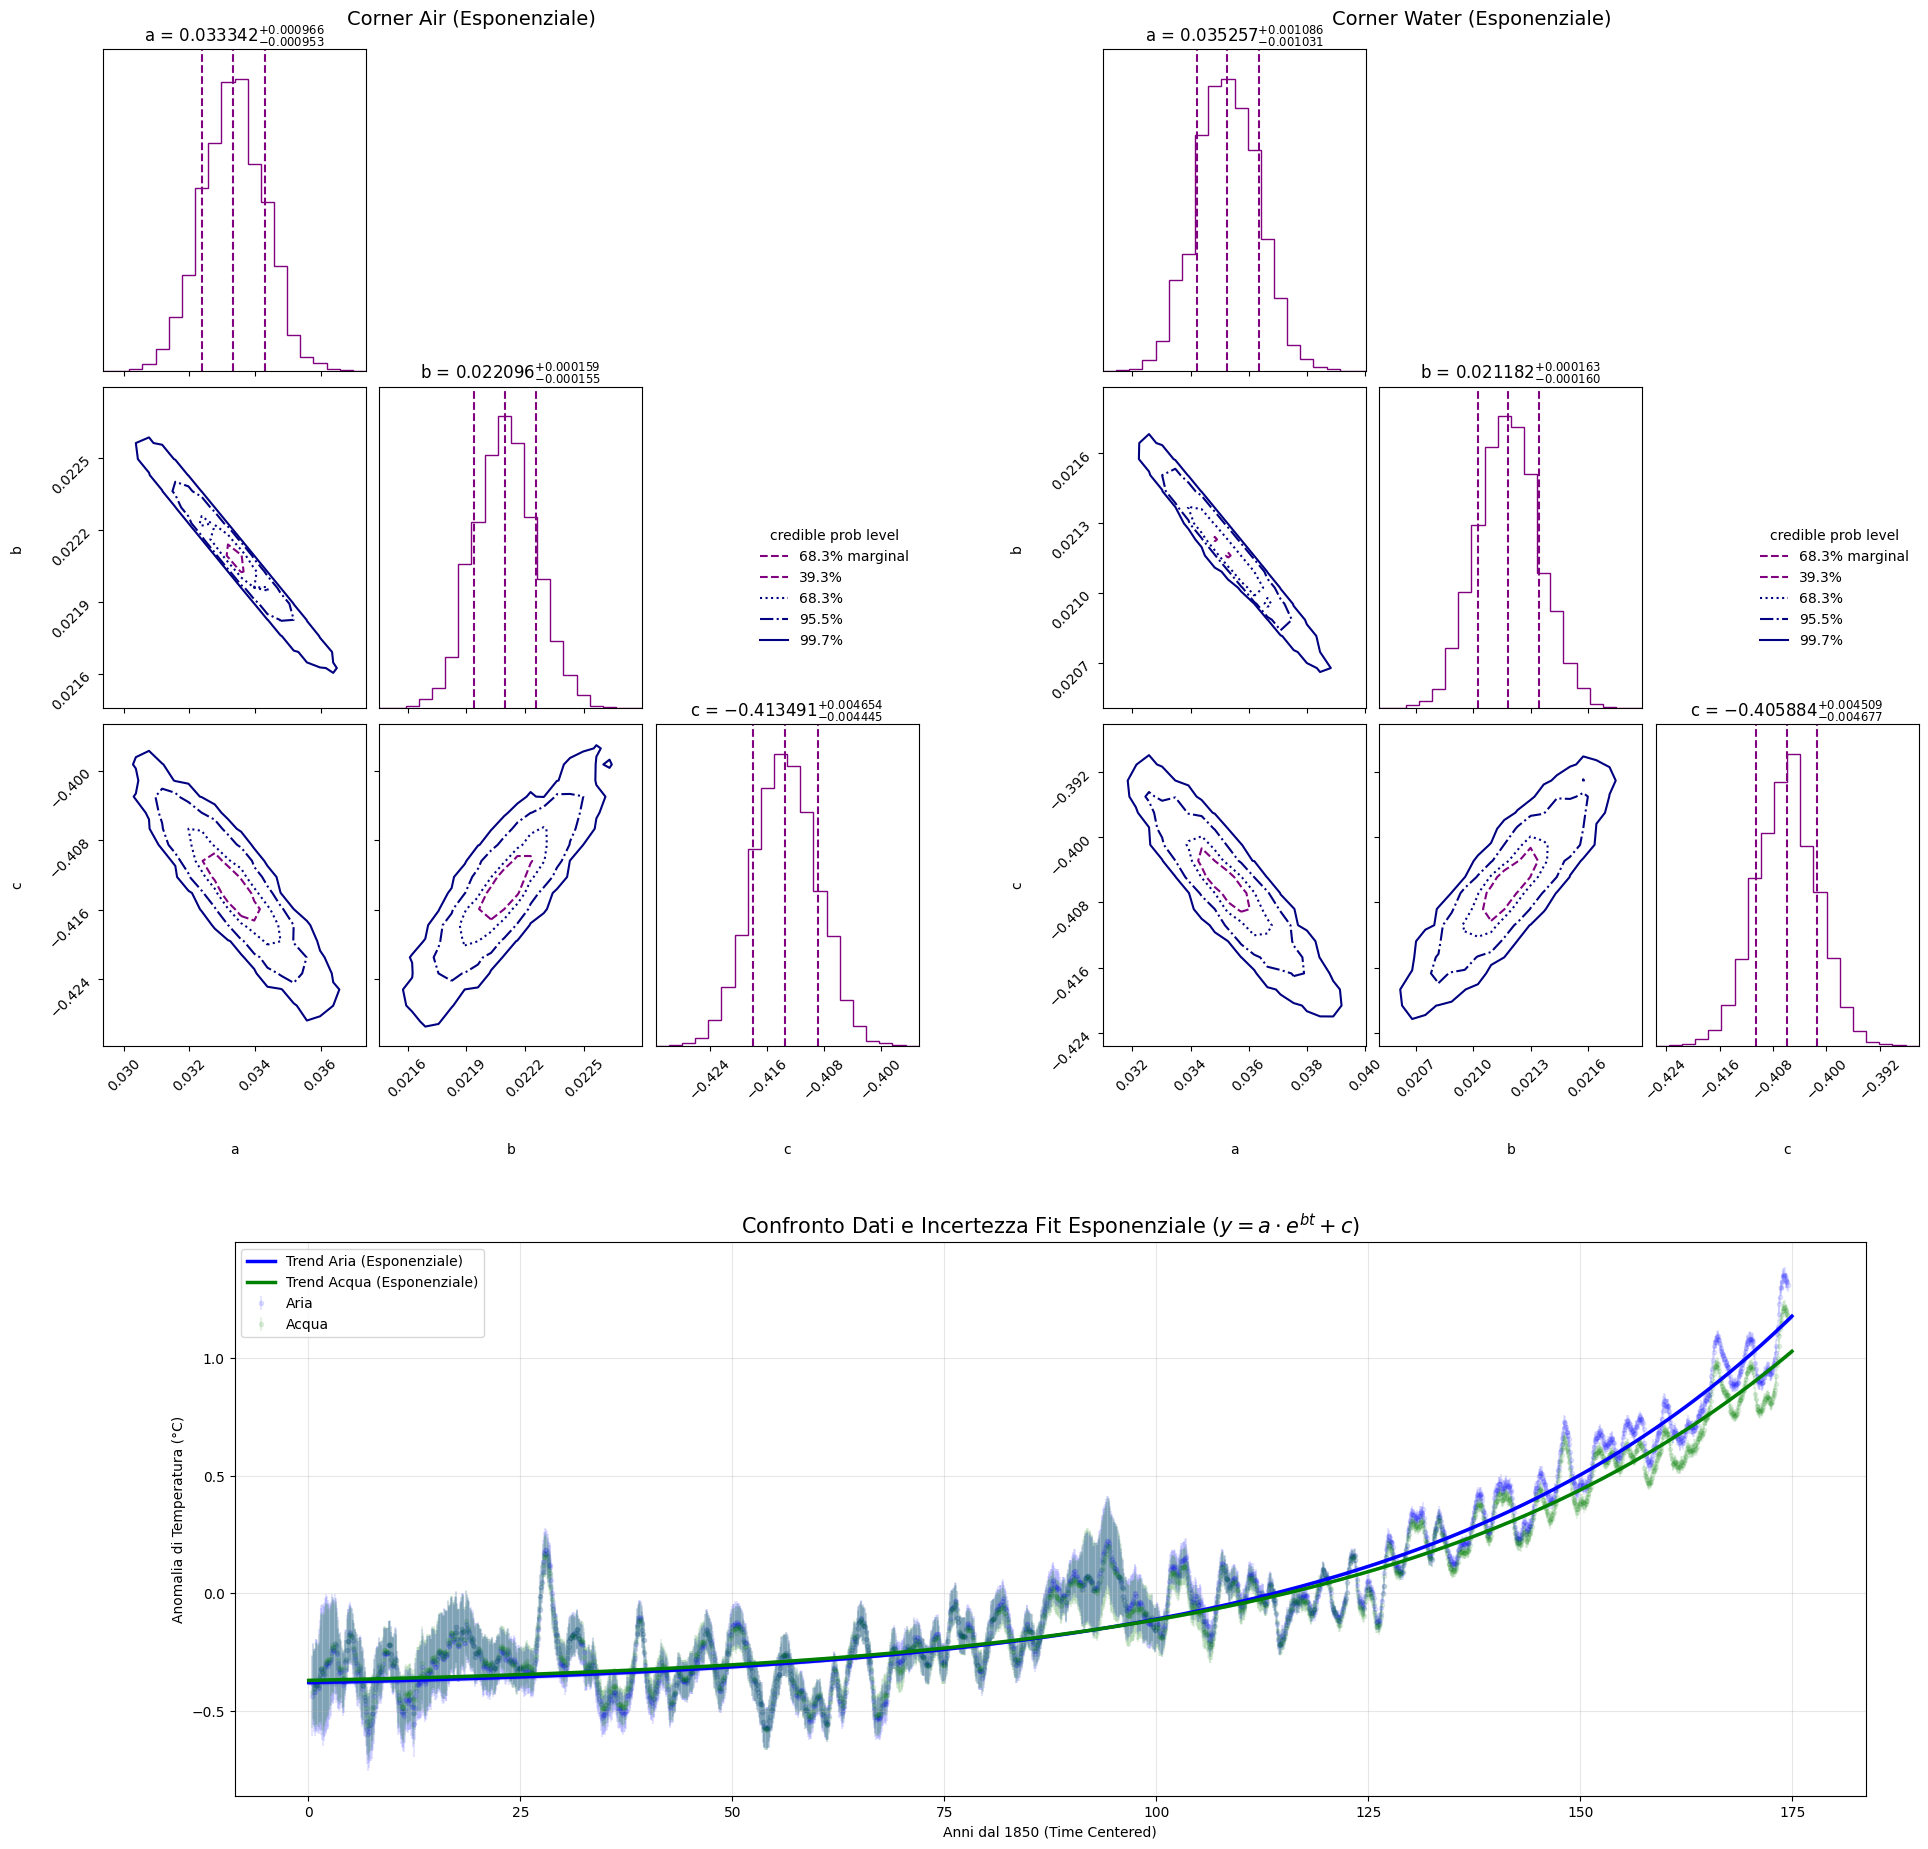

In [10]:
fig = plt.figure(figsize=(20, 19))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.8, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_exponential'], fig=corner_subfigs[0], title_fmt='.6f')
corner_subfigs[0].suptitle('Corner Air (Esponenziale)', fontsize=14)

cornerplot(results['water_exponential'], fig=corner_subfigs[1], title_fmt='.6f')
corner_subfigs[1].suptitle('Corner Water (Esponenziale)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

t_min = min(data_air['time_centered'].min(), data_water['time_centered'].min())
t_max = max(data_air['time_centered'].max(), data_water['time_centered'].max())
t_grid = np.linspace(t_min, t_max, 400)

def plot_exponential_with_bands(ax, data, res_key, color, label_prefix):
    samples = results[res_key]['samples']

    band = PredictionBand(t_grid)

    for a, b, c in samples:
        band.add(a * np.exp(b * t_grid) + c)
    
    ax.errorbar(data['time_centered'], data['Annual_Anomaly'], 
                yerr=data['Annual_Anomaly_Unc'], fmt='.', color=color, alpha=0.1, zorder=1, label=f'{label_prefix}')
    
    band.line(ax=ax, color=color, lw=2.5, label=f'Trend {label_prefix} (Esponenziale)', zorder=3)
    band.shade(ax=ax, color=color, alpha=0.3, zorder=2)         # 1-sigma (68%)
    band.shade(ax=ax, q=0.49, color=color, alpha=0.1, zorder=2)  # 2-sigma (95%)

plot_exponential_with_bands(ax, data_air, 'air_exponential', 'blue', 'Aria')
plot_exponential_with_bands(ax, data_water, 'water_exponential', 'green', 'Acqua')

ax.set_title('Confronto Dati e Incertezza Fit Esponenziale ($y = a \cdot e^{bt} + c$)', fontsize=15)
ax.set_xlabel('Anni dal 1850 (Time Centered)')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.show()

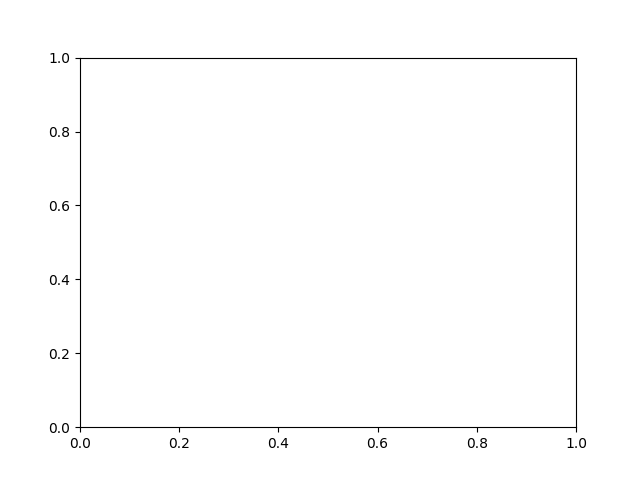

In [64]:
from IPython.display import display # Molto utile nei notebook

# 1. Genera il cornerplot. 
# Lasciamo che generi i titoli di default (è più sicuro), li sovrascriveremo dopo.
fig = cornerplot(results['air_exponential'], fig=corner_subfigs[0])

# 2. Estrai i campioni e i nomi dei parametri
samples = results['air_exponential']['samples']
param_names = results['air_exponential']['paramnames']
ndim = len(param_names)

# 3. Definisci i formati per TUTTI i parametri. 
# ATTENZIONE: Questa lista DEVE avere esattamente la stessa lunghezza di 'ndim'
# (Nel tuo modello esponenziale hai 5 parametri: a, b, c, log_constant, log_metric)
formattazioni = ['.2f', '.6f', '.3f', '.1f', '.1f'] 

# 4. Ottieni gli assi e trasformali nella griglia
axes = np.array(fig.axes).reshape((ndim, ndim))

# 5. Sovrascrivi i titoli sulla diagonale
for i in range(ndim):
    ax = axes[i, i]
    
    # Calcola i quantili
    q_16, q_50, q_84 = np.percentile(samples[:, i], [16, 50, 84])
    q_minus = q_50 - q_16
    q_plus = q_84 - q_50
    
    # Costruisci il nuovo titolo
    fmt = formattazioni[i]
    titolo = f"{param_names[i]} = {q_50:{fmt}} (+{q_plus:{fmt}} / -{q_minus:{fmt}})"
    
    # Sovrascrive il titolo e imposta una dimensione del font leggibile
    ax.set_title(titolo, fontsize=11)

# 6. FORZA IL RENDERING (Essenziale per Jupyter Notebook)
# Questo aggiorna la "tela" con le nostre modifiche
fig.canvas.draw()

# Opzione A: Se usi %matplotlib inline o widget
display(fig) 

# Opzione B: In alternativa, puoi usare
#plt.show()

## Models comparison

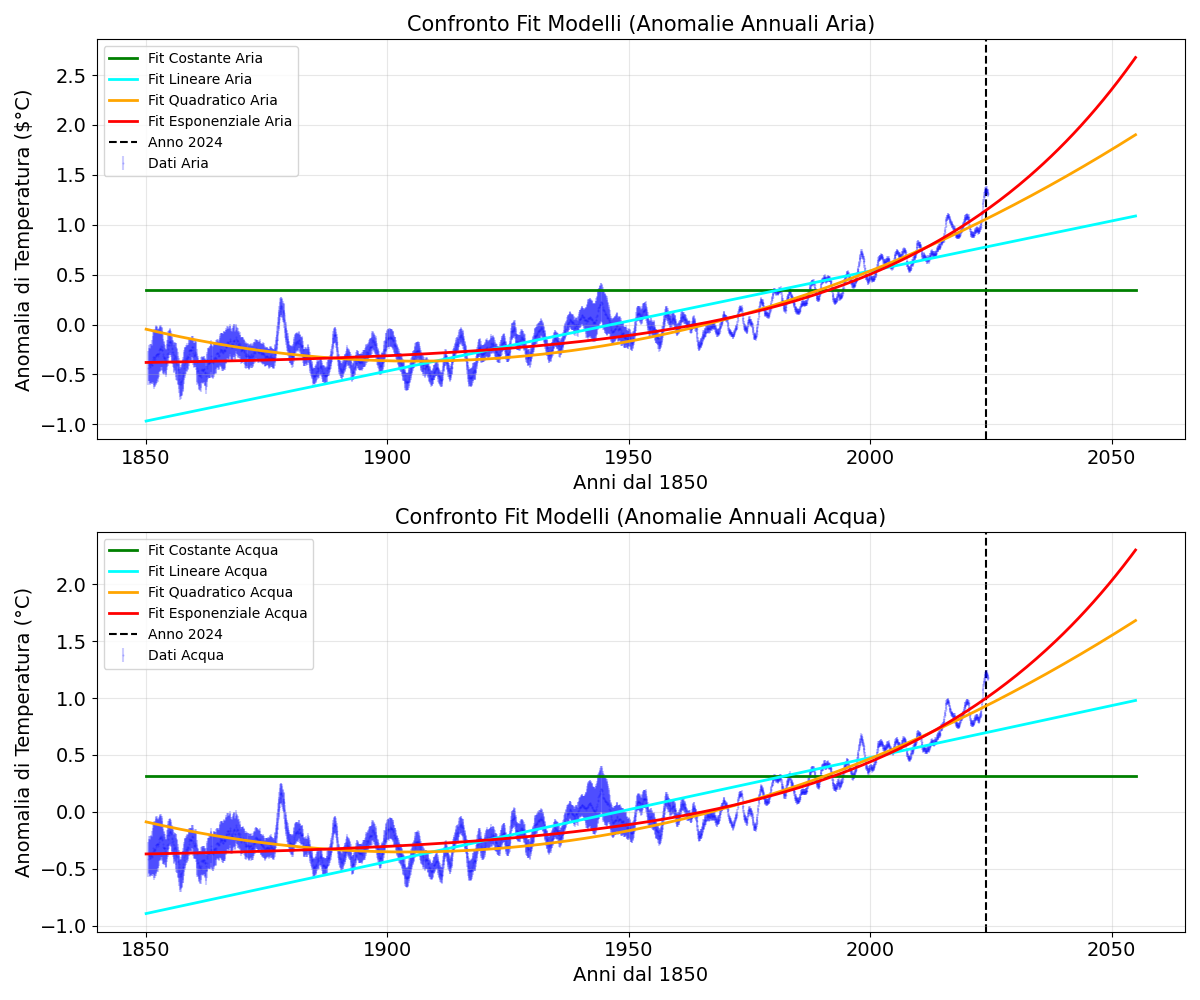

In [ ]:

t_max = data_air['time_centered'].max()
t_grid = np.linspace(0 ,t_max+30, 400) 
t_grid_scaled = t_grid + 1850

sigma_a_air = np.var(results['air_exponential']['samples'][:, 0])**0.5  # Deviazione standard del parametro 'a' (ampiezza)
sigma_b_air = np.var(results['air_exponential']['samples'][:, 1])**0.5  # Deviazione standard del parametro 'b' (tasso di crescita)
sigma_c_air = np.var(results['air_exponential']['samples'][:, 2])**0.5  # Deviazione standard del parametro 'c' (offset)

sigma_a_water = np.var(results['water_exponential']['samples'][:, 0])**0.5  # Deviazione standard del parametro 'a' (ampiezza)
sigma_b_water = np.var(results['water_exponential']['samples'][:, 1])**0.5  # Deviazione standard del parametro 'b' (tasso di crescita) 
sigma_c_water = np.var(results['water_exponential']['samples'][:, 2])**0.5  # Deviazione standard del parametro 'c' (offset)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Creiamo una condizione logica: "Vero" solo per gli anni successivi all'ultimo dato
solo_futuro = t_grid >= (2024)

# Plot della fascia di incertezza (SOLO NEL FUTURO grazie a where=solo_futuro)
ax1.fill_between(t_grid_scaled, , sigma_a_air*exponential_model(t_grid, np.median(results['air_exponential']['samples'][:, 0]), np.median(results['air_exponential']['samples'][:, 1]), np.median(results['air_exponential']['samples'][:, 2])) + sigma_c_air,
                 where=solo_futuro, color='red', alpha=0.15, label='Incertezza Costante')
# --- Dati Aria ---
ax1.errorbar(data_air['time_centered']+ 1850, data_air['Annual_Anomaly'], yerr=data_air['Annual_Anomaly_Unc'], fmt='.b', markersize=1, 
             zorder=1, alpha=0.2, label='Dati Aria')
ax1.plot(t_grid_scaled, constant_model(t_grid, np.median(results['air_const']['samples'])), color='green', lw=2, label='Fit Costante Aria', zorder=2)
ax1.plot(t_grid_scaled, linear_model(t_grid, *np.median(results['air_linear']['samples'], axis=0)), color='cyan', lw=2, label='Fit Lineare Aria', zorder=2)
ax1.plot(t_grid_scaled, quadratic_model(t_grid, *np.median(results['air_quadratic']['samples'], axis=0)), color='orange', lw=2, label='Fit Quadratico Aria', zorder=2)
ax1.plot(t_grid_scaled, exponential_model(t_grid, *np.median(results['air_exponential']['samples'], axis=0)), color='red', lw=2, label='Fit Esponenziale Aria', zorder=2)
ax1.axvline(2024, color='black', linestyle='--', zorder=0, label='Anno 2024')
ax1.set_xlabel('Anni dal 1850', fontsize=14)
ax1.set_ylabel('Anomalia di Temperatura ($°C)', fontsize=14)
ax1.tick_params(labelsize=14)
ax1.set_title('Confronto Fit Modelli (Anomalie Annuali Aria)', fontsize=15)
ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)

# --- Dati Acqua ---
ax2.errorbar(data_water['time_centered'] + 1850, data_water['Annual_Anomaly'],  yerr=data_water['Annual_Anomaly_Unc'], fmt='.b', markersize=1, 
             zorder=1, alpha=0.2, label='Dati Acqua')
ax2.plot(t_grid_scaled, constant_model(t_grid, np.median(results['water_const']['samples'])), color='green', lw=2, label='Fit Costante Acqua', zorder=2)
ax2.plot(t_grid_scaled, linear_model(t_grid, *np.median(results['water_linear']['samples'], axis=0)), color='cyan', lw=2, label='Fit Lineare Acqua', zorder=2)
ax2.plot(t_grid_scaled, quadratic_model(t_grid, *np.median(results['water_quadratic']['samples'], axis=0)), color='orange', lw=2, label='Fit Quadratico Acqua', zorder=2)
ax2.plot(t_grid_scaled, exponential_model(t_grid, *np.median(results['water_exponential']['samples'], axis=0)), color='red', lw=2, label='Fit Esponenziale Acqua', zorder=2)
ax2.axvline(2024, color='black', linestyle='--', zorder=0, label='Anno 2024')
ax2.set_xlabel('Anni dal 1850', fontsize=14)
ax2.set_ylabel('Anomalia di Temperatura (°C)', fontsize=14)
ax2.tick_params(labelsize=14)
ax2.set_title('Confronto Fit Modelli (Anomalie Annuali Acqua)', fontsize=15)
ax2.legend(loc='upper left')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('confronto_fit_aria_acqua.png')
plt.show()


In [ ]:
dataset_labels = ['air', 'water']
model_labels = ['const', 'linear', 'quadratic', 'exponential']

for data_l in dataset_labels:
    print(f"\n--- CONFRONTO MODELLI PER DATASET (REF = COSTANTE): {data_l.upper()} ---")
    print(f"{'Modello':<15} | {'logZ':<12} | {'Delta logZ':<12}")
    print("-" * 45)

    res0 = results[f"{data_l}_const"]
    logz0 = res0['logz']
    
    for mod_l in model_labels:
        res = results[f"{data_l}_{mod_l}"]
        logz = res['logz']
        delta = logz - logz0
        
        print(f"{mod_l:<15} | {logz:12.2f} | {delta:12.2f}")

for data_l in dataset_labels:
    print(f"\n--- CONFRONTO MODELLI PER DATASET (REF = LINEARE): {data_l.upper()} ---")
    print(f"{'Modello':<15} | {'logZ':<12} | {'Delta logZ':<12}")
    print("-" * 45)

    res0 = results[f"{data_l}_linear"]
    logz0 = res0['logz']
    
    for mod_l in model_labels:
        res = results[f"{data_l}_{mod_l}"]
        logz = res['logz']
        delta = logz - logz0
        
        print(f"{mod_l:<15} | {logz:12.2f} | {delta:12.2f}")

for data_l in dataset_labels:
    print(f"\n--- CONFRONTO MODELLI PER DATASET (REF = QUADRATICO): {data_l.upper()} ---")
    print(f"{'Modello':<15} | {'logZ':<12} | {'Delta logZ':<12}")
    print("-" * 45)

    res0 = results[f"{data_l}_quadratic"]
    logz0 = res0['logz']
    
    for mod_l in model_labels:
        res = results[f"{data_l}_{mod_l}"]
        logz = res['logz']
        delta = logz - logz0
        
        print(f"{mod_l:<15} | {logz:12.2f} | {delta:12.2f}")

for data_l in dataset_labels:
    print(f"\n--- CONFRONTO MODELLI PER DATASET (REF = ESPONENZIALE): {data_l.upper()} ---")
    print(f"{'Modello':<15} | {'logZ':<12} | {'Delta logZ':<12}")
    print("-" * 45)

    res0 = results[f"{data_l}_exponential"]
    logz0 = res0['logz']
    
    for mod_l in model_labels:
        res = results[f"{data_l}_{mod_l}"]
        logz = res['logz']
        delta = logz - logz0
        
        print(f"{mod_l:<15} | {logz:12.2f} | {delta:12.2f}")


--- CONFRONTO MODELLI PER DATASET (REF = COSTANTE): AIR ---
Modello         | logZ         | Delta logZ  
---------------------------------------------
const           |    -81425.13 |         0.00
linear          |    -20205.65 |     61219.49
quadratic       |     -2172.31 |     79252.82
exponential     |     -1703.50 |     79721.63

--- CONFRONTO MODELLI PER DATASET (REF = COSTANTE): WATER ---
Modello         | logZ         | Delta logZ  
---------------------------------------------
const           |    -74219.88 |         0.00
linear          |    -18251.16 |     55968.73
quadratic       |     -1983.27 |     72236.61
exponential     |     -1709.50 |     72510.39

--- CONFRONTO MODELLI PER DATASET (REF = LINEARE): AIR ---
Modello         | logZ         | Delta logZ  
---------------------------------------------
const           |    -81425.13 |    -61219.49
linear          |    -20205.65 |         0.00
quadratic       |     -2172.31 |     18033.33
exponential     |     -1703.50 |  

## Gaussian process trend (exp)

In [ ]:
class Exp(Model):
    parameter_names = ("a", "b", "c")

    def get_value(self, t):
        return self.a * np.exp(self.b * t) + self.c

exp_model = george.GP(kernel=kernels.ExpSquaredKernel(1.0), mean=Exp(a=0.0, b=0.0, c=0.0))
exp_model.compute(data_air_masked['time_centered'], data_air_masked['Annual_Anomaly_Unc'])

# print(exp_model.get_parameter_names(include_frozen=True))

def log_likelihood(params):
    exp_model.set_parameter_vector(params)
    return exp_model.log_likelihood(data_air_masked['Annual_Anomaly'], quiet=True)


param_names_GP_trend = ['a', 'b', 'c']
sampler_GP_trend = ReactiveNestedSampler(param_names_GP_trend, loglike=log_likelihood, transform=prior_exponential)
results_GP_trend = sampler_GP_trend.run(min_num_live_points=100)
sampler_GP_trend.print_results()

ValueError: NumPy boolean array indexing assignment cannot assign 3 input values to the 4 output values where the mask is true

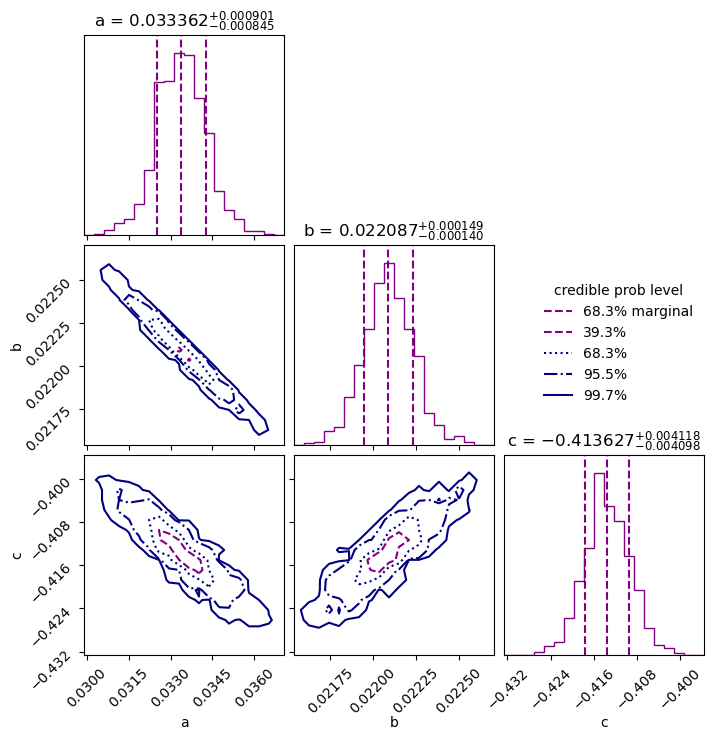

In [ ]:
cornerplot(results_GP_trend, title_fmt='.6f');

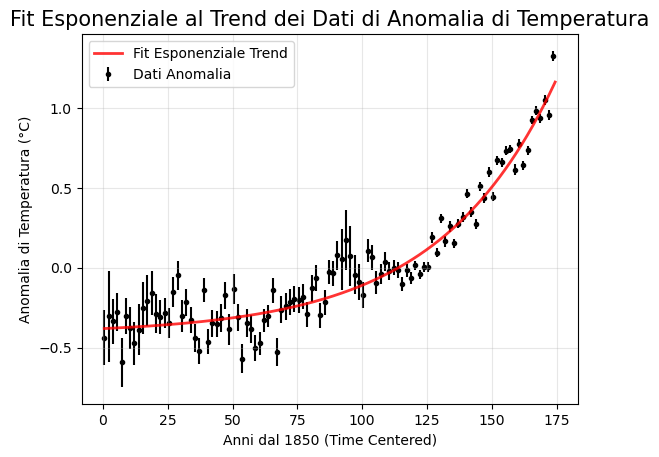

In [ ]:
a = results_GP_trend['samples'][:, 0].mean()
b = results_GP_trend['samples'][:, 1].mean()
c = results_GP_trend['samples'][:, 2].mean()

t = data_air_masked['time_centered']
pred_trend = a * np.exp(b * t) + c

plt.errorbar(t[::20],data_air_masked['Annual_Anomaly'][::20], yerr=data_air_masked['Annual_Anomaly_Unc'][::20], fmt=".k", capsize=0, zorder=0)
plt.plot(t, pred_trend, "r", lw=2, alpha=0.8, label='Fit Esponenziale (Trend)')
plt.legend(['Fit Esponenziale Trend', 'Dati Anomalia'])
plt.title('Fit Esponenziale al Trend dei Dati di Anomalia di Temperatura', fontsize=15)
plt.xlabel('Anni dal 1850 (Time Centered)')
plt.ylabel('Anomalia di Temperatura (°C)')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
arr1 = data_air_masked['time_centered']
arr2 = data_air_masked['Annual_Anomaly']

corr_matrix_time_anomaly = np.corrcoef(arr1, arr2)
correlazione_time_anomaly = corr_matrix_time_anomaly[0, 1]

print(f"Coefficiente di correlazione di Pearson (Time vs Anomalia): {correlazione_time_anomaly:.4f}")

arr3 = data_air_masked['Annual_Anomaly_Unc']
corr_matrix_anomaly_unc = np.corrcoef(arr2, arr3)
correlazione_anomaly_unc = corr_matrix_anomaly_unc[0, 1]

print(f"Coefficiente di correlazione di Pearson (Anomalia vs Incertezza): {correlazione_anomaly_unc:.4f}")

corr_matrix_time_unc = np.corrcoef(arr1, arr3)
correlazione_time_unc = corr_matrix_time_unc[0, 1]

print(f"Coefficiente di correlazione di Pearson (Time vs Incertezza): {correlazione_time_unc:.4f}")

Coefficiente di correlazione di Pearson (Time vs Anomalia): 0.8581
Coefficiente di correlazione di Pearson (Anomalia vs Incertezza): -0.5791
Coefficiente di correlazione di Pearson (Time vs Incertezza): -0.7683
